In [6]:
from ultralytics.models.yolo import YOLO

saved_model_path = (
    "E:/Projects/tp_yolo/runs/segment/train6/weights/best_saved_model/best_float32.tflite"
)

saved_model = YOLO(saved_model_path)

In [7]:
import cv2
import matplotlib.pyplot as plt


In [8]:
import torch

torch.cuda.is_available()

True

In [9]:
TEST_IMAGE_PATH = "../data/Test-TP-2.png"
image = cv2.imread(TEST_IMAGE_PATH)

results = saved_model.predict(
    source=TEST_IMAGE_PATH,
    conf=0.25,
    show=True,
    device=0,
)

results


Loading E:/Projects/tp_yolo/runs/segment/train6/weights/best_saved_model/best_float32.tflite for TensorFlow Lite inference...



c:\Users\liste\miniconda3\envs\tfenv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


image 1/1 e:\Projects\tp_yolo\notebooks\..\data\Test-TP-2.png: 640x640 1 tactile_paving, 92.7ms
Speed: 3.6ms preprocess, 92.7ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'tactile_paving'}
 obb: None
 orig_img: array([[[ 90,  86,  85],
         [ 88,  84,  83],
         [ 84,  80,  79],
         ...,
         [155, 154, 150],
         [155, 154, 150],
         [154, 153, 149]],
 
        [[108, 104, 103],
         [107, 103, 102],
         [106, 102, 101],
         ...,
         [155, 154, 150],
         [155, 154, 150],
         [154, 153, 149]],
 
        [[103,  98,  97],
         [103,  99,  98],
         [104, 100,  99],
         ...,
         [155, 154, 150],
         [155, 154, 150],
         [154, 153, 149]],
 
        ...,
 
        [[133, 131, 133],
         [132, 130, 132],
         [132, 129, 130],
         ...,
         [102,  93,  84],
         [103,  93,  85],
         [103,  93,  86]],
 
        [[128, 127, 130],
         [129, 128, 131],
         [130, 

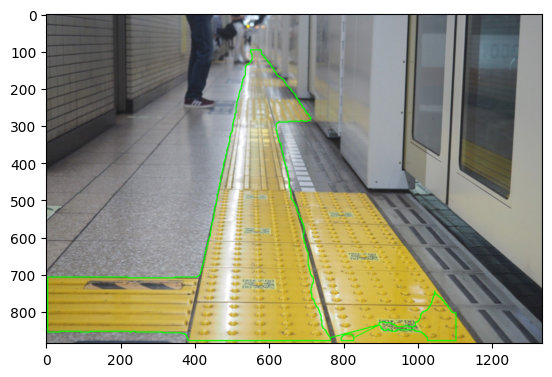

In [10]:
for result in results:
    contour = result.masks.xy
    for cnt in contour:
        cnt = cnt.astype(int)
        cv2.polylines(image, [cnt], isClosed=True, color=(0, 255, 0), thickness=2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))